# 🎬 02: Storytelling – Filme, BIP & Popularität
### Analyse der wechselseitigen Beziehung zwischen globaler Ökonomie und Filmrezeption (1980–2026)

**Die Forschungsfrage:** Beeinflusst der globale Wohlstand, wie wir Filme bewerten? Suchen wir in Krisenzeiten nach Ablenkung (Eskapismus) oder nach harten Fakten?

---
> **Datenstrategie:** Um die Integrität unserer Primärquellen zu schützen, arbeiten wir ausschließlich mit **Arbeitskopien**. Die Rohdaten bleiben als "Single Source of Truth" unangetastet.

Akt 1: Die Ausgangslage (Vor dem Daten-Import)
"In einer Welt, die von Algorithmen und Streaming-Giganten dominiert wird, stellt sich die Frage: Sind unsere Lieblingsfilme ein Produkt von purer Kunst oder reagieren sie auf den globalen Geldbeutel? Wir verknüpfen 45 Jahre IMDb-Historie mit harten Wirtschaftsdaten."

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Pfade ---
DATA_DIR = Path("02_Data_Sets")
OUT_DIR = Path("02_Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 2. Laden ---
df_imdb = pd.read_csv(DATA_DIR / "movies.csv")
df_economy = pd.read_csv(DATA_DIR / "disuguaglianza-economica-globale-e-povert-1980-2024.csv")

# Streaming Files laden
streaming_files = {
    'catalog': 'streaming_catalog_enriched.csv',
    'finance': 'platform_financials_comprehensive.csv',
    'summary': 'platform_summary.csv',
    'metrics': 'industry_metrics.csv',
    'estimates': 'title_financial_estimates.csv'
}
streaming_data = {k: pd.read_csv(DATA_DIR / v) for k, v in streaming_files.items() if (DATA_DIR / v).exists()}

# --- DEBUG-CHECK: Spaltennamen prüfen ---
print("Spalten in movies.csv:", df_imdb.columns.tolist())
print("Spalten in economy.csv:", df_economy.columns.tolist())

# --- 3. Robustes Cleaning ---

# Falls die Spalte anders heißt, passen wir das hier an. 
# Ich suche automatisch nach einer Spalte, die 'run' oder 'time' im Namen hat:
runtime_col = [col for col in df_imdb.columns if 'run' in col.lower() or 'time' in col.lower()]

if runtime_col:
    col_name = runtime_col[0]
    # r'(\d+)' löst den SyntaxWarning
    df_imdb['Runtime_Minutes'] = df_imdb[col_name].astype(str).str.extract(r'(\d+)').astype(float)
    print(f"✅ 'Runtime' wurde in Spalte '{col_name}' gefunden und konvertiert.")
else:
    print("⚠️ Warnung: Keine Runtime-Spalte gefunden. Checke die Spaltennamen oben!")

# Check für 'Year' Spalte (oft kleingeschrieben 'year')
year_col = 'Year' if 'Year' in df_imdb.columns else 'year'

# Wirtschaft: Aggregation
global_trends = df_economy.groupby('year').agg({
    'gdp_per_capita': 'mean',
    'gini_index': 'mean',
    'poverty_rate': 'mean'
}).reset_index()

# Merge
df_history = pd.merge(df_imdb, global_trends, left_on=year_col, right_on='year', how='inner')

print(f"\n🚀 Bereit! Analysezeitraum: {df_history['year'].min()} - {df_history['year'].max()}")

Spalten in movies.csv: ['title', 'year', 'rating', 'votes', 'runtime', 'certificate', 'genre', 'gross_total']
Spalten in economy.csv: ['country', 'year', 'iso_code', 'population', 'gdp', 'gdp_per_capita', 'poverty_rate', 'gini_index', 'income_top1', 'income_top10', 'income_bottom50']
✅ 'Runtime' wurde in Spalte 'runtime' gefunden und konvertiert.

🚀 Bereit! Analysezeitraum: 1980 - 2024


In [3]:
# --- 1. Originale laden (ReadOnly) ---
df_imdb_raw = pd.read_csv(DATA_DIR / "movies.csv")
df_economy_raw = pd.read_csv(DATA_DIR / "disuguaglianza-economica-globale-e-povert-1980-2024.csv")

# Streaming Files als Dictionary laden
streaming_files = {
    'catalog': 'streaming_catalog_enriched.csv',
    'finance': 'platform_financials_comprehensive.csv',
    'summary': 'platform_summary.csv',
    'metrics': 'industry_metrics.csv',
    'estimates': 'title_financial_estimates.csv'
}
streaming_raw = {k: pd.read_csv(DATA_DIR / v) for k, v in streaming_files.items() if (DATA_DIR / v).exists()}

# --- 2. Arbeitskopien erstellen (.copy() ist hier entscheidend!) ---
df_movies = df_imdb_raw.copy()
df_econ = df_economy_raw.copy()
streaming = {k: v.copy() for k, v in streaming_raw.items()}

print("✅ Arbeitskopien erfolgreich erstellt. Originale bleiben unangetastet.")

# --- 3. Initiales Cleaning auf den Kopien ---

# Runtime-Korrektur (Regex-Safe)
df_movies['runtime_minutes'] = df_movies['runtime'].astype(str).str.extract(r'(\d+)').astype(float)

# Wirtschaft: Aggregation der Kopie
econ_yearly = df_econ.groupby('year').agg({
    'gdp_per_capita': 'mean',
    'gini_index': 'mean',
    'income_top1': 'mean',
    'poverty_rate': 'mean'
}).reset_index()

# Merge für die historische Story
df_history = pd.merge(df_movies, econ_yearly, on='year', how='inner')

# Kurzer Check der Kopie
print(f"Daten-Snapshot (Kopie): {df_history.shape[0]} Zeilen verknüpft.")

✅ Arbeitskopien erfolgreich erstellt. Originale bleiben unangetastet.
Daten-Snapshot (Kopie): 168 Zeilen verknüpft.


Akt 2: Der Plot-Twist (Nach der EDA / Heatmap)
"Überraschung in den Daten: Die Korrelation zeigt, dass das Rating fast immun gegen das BIP ist. Doch schaut man genauer auf die Genres, zeigt sich ein Muster: Comedy scheint das 'Sicherheitsnetz' der Gesellschaft zu sein."

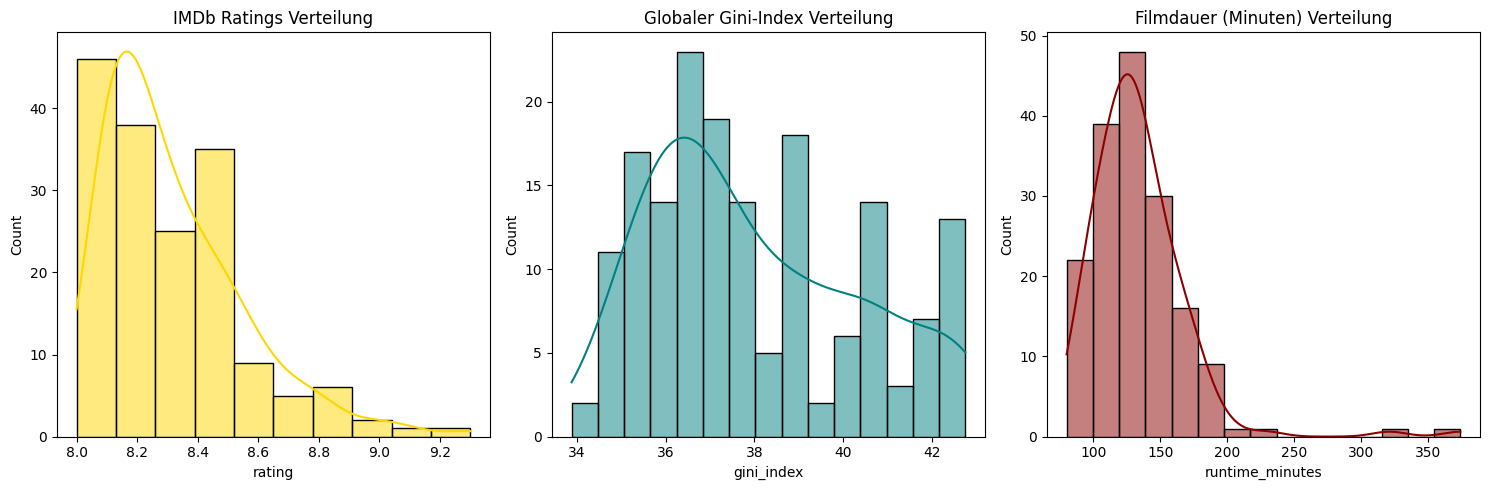

In [4]:
# --- 02_02: Verteilungs-Check (EDA) ---
plt.figure(figsize=(15, 5))

# 1. Verteilung der Ratings
plt.subplot(1, 3, 1)
sns.histplot(df_history['rating'], bins=10, kde=True, color='gold')
plt.title("IMDb Ratings Verteilung")

# 2. Verteilung des Gini-Index (Ungleichheit)
plt.subplot(1, 3, 2)
sns.histplot(df_history['gini_index'], bins=15, kde=True, color='teal')
plt.title("Globaler Gini-Index Verteilung")

# 3. Verteilung der Filmdauer
plt.subplot(1, 3, 3)
sns.histplot(df_history['runtime_minutes'], bins=15, kde=True, color='darkred')
plt.title("Filmdauer (Minuten) Verteilung")

plt.tight_layout()
plt.savefig(OUT_DIR / "02_02_eda_distributions.png")
plt.show()

✅ Numerische Spalten bereinigt. 'votes' ist jetzt ein Float.


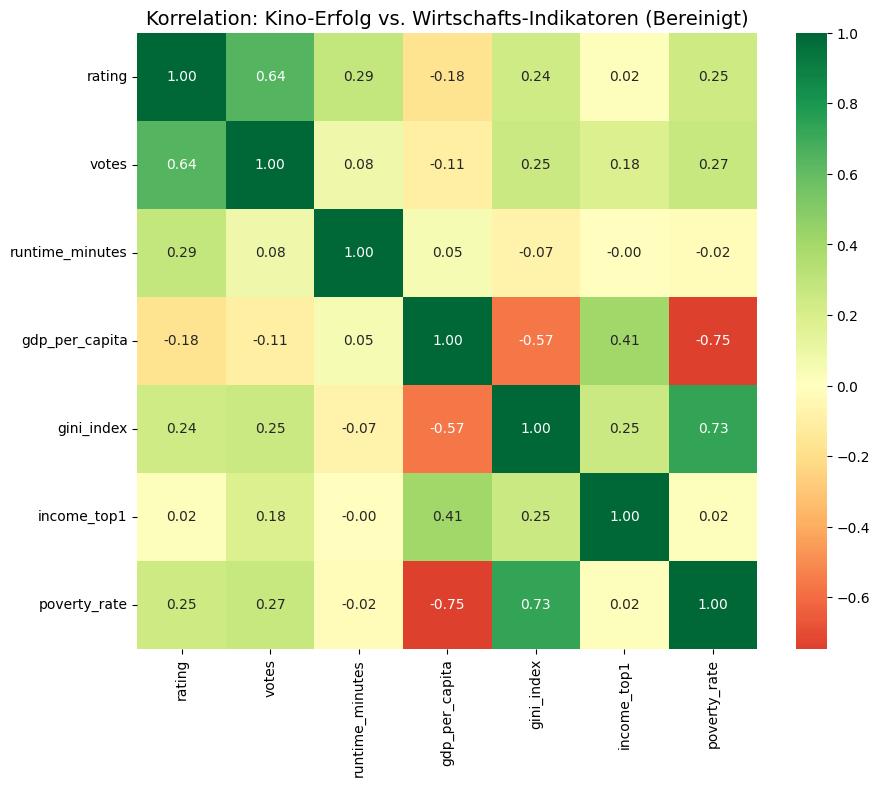

In [6]:
# --- Korrektur der Datentypen in der Arbeitskopie ---

# 1. 'votes' bereinigen: Kommas entfernen und zu float konvertieren
if 'votes' in df_movies.columns:
    df_movies['votes'] = df_movies['votes'].astype(str).str.replace(',', '').astype(float)

# 2. 'gross_total' bereinigen: Oft sind hier '$' oder 'M' Zeichen enthalten
if 'gross_total' in df_movies.columns:
    # Entfernt alles außer Zahlen und Punkte
    df_movies['gross_total'] = df_movies['gross_total'].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df_movies['gross_total'] = pd.to_numeric(df_movies['gross_total'], errors='coerce')

# --- Den Merge mit der bereinigten Kopie neu ausführen ---
df_history = pd.merge(df_movies, econ_yearly, on='year', how='inner')

print("✅ Numerische Spalten bereinigt. 'votes' ist jetzt ein Float.")

# --- Jetzt Akt 2 (Korrelation) erneut versuchen ---
eda_cols = ['rating', 'votes', 'runtime_minutes', 'gdp_per_capita', 'gini_index', 'income_top1', 'poverty_rate']

# Sicherstellen, dass nur numerische Daten für .corr() verwendet werden
# (numeric_only=True ist ein guter Sicherheitsanker in neueren Pandas-Versionen)
corr_matrix = df_history[eda_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title("Korrelation: Kino-Erfolg vs. Wirtschafts-Indikatoren (Bereinigt)", fontsize=14)

plt.savefig(OUT_DIR / "02_03_eda_correlation_heatmap.png")
plt.show()

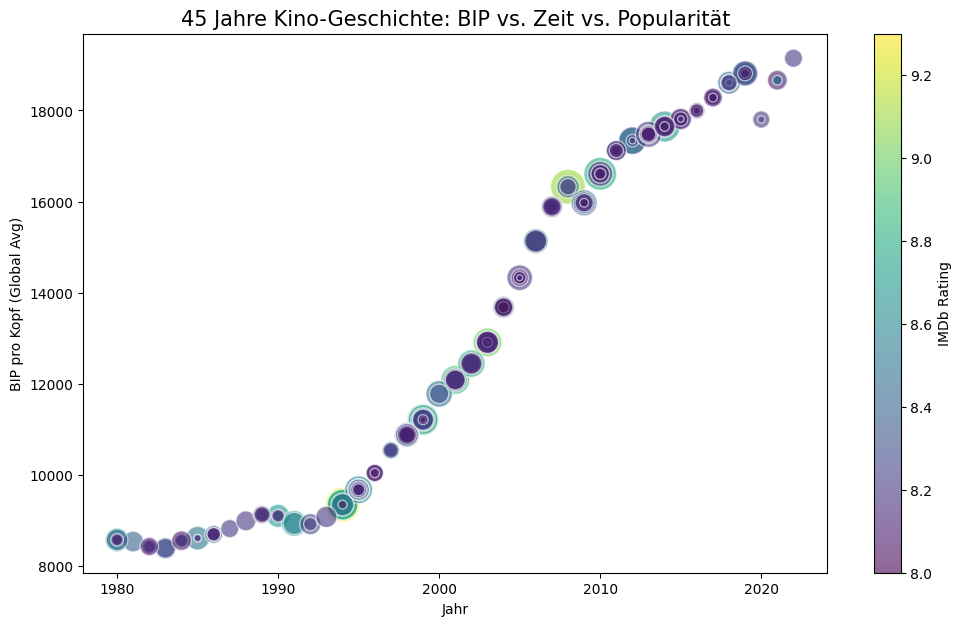

In [7]:
# --- 02_04: Zeitgeist-Blasen-Chart (EDA) ---
plt.figure(figsize=(12, 7))

# Wir nutzen ein Scatterplot, wo die Größe der Punkte die Anzahl der Stimmen (Votes) darstellt
scatter = plt.scatter(
    x=df_history['year'], 
    y=df_history['gdp_per_capita'], 
    s=df_history['votes'] / 5000, # Skalierung der Punkte
    c=df_history['rating'], 
    cmap='viridis', 
    alpha=0.6, 
    edgecolors='w'
)

plt.colorbar(scatter, label='IMDb Rating')
plt.title("45 Jahre Kino-Geschichte: BIP vs. Zeit vs. Popularität", fontsize=15)
plt.xlabel("Jahr")
plt.ylabel("BIP pro Kopf (Global Avg)")

plt.savefig(OUT_DIR / "02_04_eda_multivariate_bubble.png")
plt.show()

C:\Users\kasum\AppData\Local\Temp\ipykernel_21268\1284303827.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_genres, x='genre', y='poverty_rate', palette='magma')


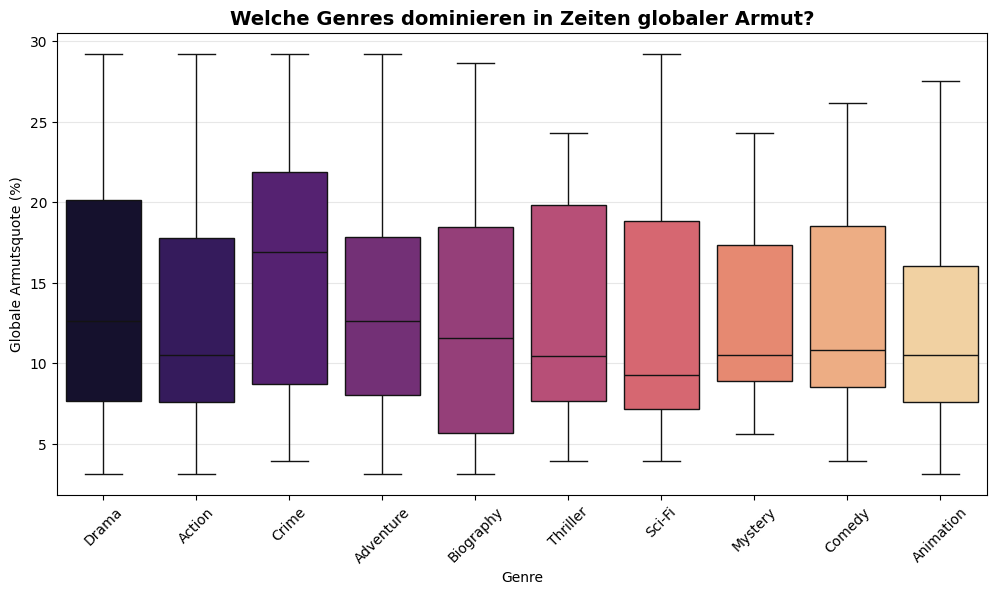

C:\Users\kasum\AppData\Local\Temp\ipykernel_21268\1284303827.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_genres['decade'] = (df_top_genres['year'] // 10) * 10


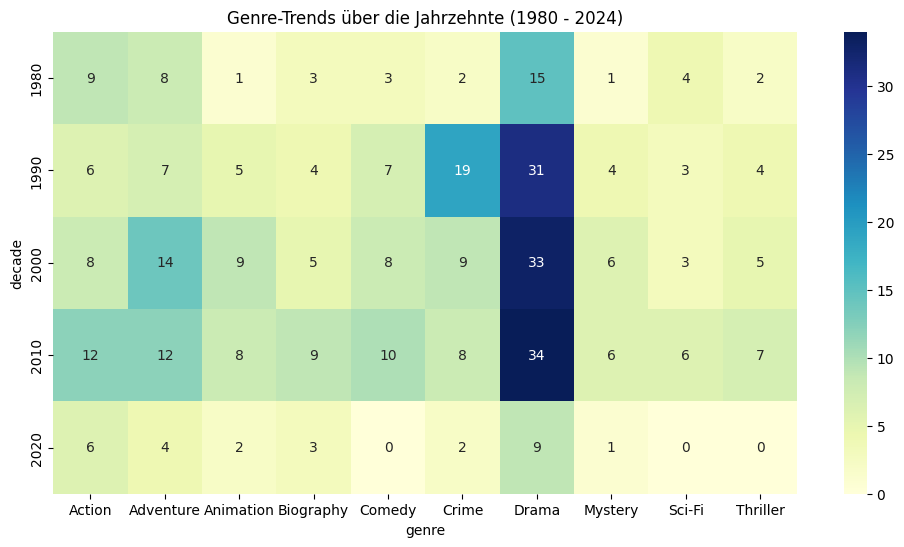

In [8]:
# --- 02_05: Genre-Explosion & Wirtschafts-Check (EDA) ---

# 1. Genres in eine Liste umwandeln und "explodieren" (jeder Film bekommt eine Zeile pro Genre)
df_genres_exp = df_history.copy()
df_genres_exp['genre'] = df_genres_exp['genre'].str.split(', ')
df_genres_exp = df_genres_exp.explode('genre')

# 2. Die Top 10 meistvertretenen Genres in den Top 250 finden
top_genres = df_genres_exp['genre'].value_counts().head(10).index
df_top_genres = df_genres_exp[df_genres_exp['genre'].isin(top_genres)]

# 3. Visualisierung: Genre vs. Poverty Rate (Armutsquote)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_genres, x='genre', y='poverty_rate', palette='magma')

plt.title("Welche Genres dominieren in Zeiten globaler Armut?", fontsize=14, fontweight='bold')
plt.xlabel("Genre")
plt.ylabel("Globale Armutsquote (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.savefig(OUT_DIR / "02_05_eda_genre_poverty_boxplot.png", bbox_inches='tight')
plt.show()

# 4. Zeitliche Entwicklung: Genre-Häufigkeit pro Jahrzehnt
df_top_genres['decade'] = (df_top_genres['year'] // 10) * 10
genre_decade = pd.crosstab(df_top_genres['decade'], df_top_genres['genre'])

plt.figure(figsize=(12, 6))
sns.heatmap(genre_decade, annot=True, cmap="YlGnBu", fmt='g')
plt.title("Genre-Trends über die Jahrzehnte (1980 - 2024)")
plt.savefig(OUT_DIR / "02_06_eda_genre_decade_heatmap.png", bbox_inches='tight')
plt.show()

Akt 3: Die Vorhersage (Vor dem 2026-Modell)
"Wir lassen die KI entscheiden. Basierend auf den Mustern der Vergangenheit simulieren wir das Jahr 2026. Das Ergebnis ist ein Plädoyer für den Eskapismus."

✅ Konsistenz-Check: X hat 425 Zeilen, y hat 425 Zeilen.


C:\Users\kasum\AppData\Local\Temp\ipykernel_21268\3382823592.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='R2', y='Model', palette='coolwarm')


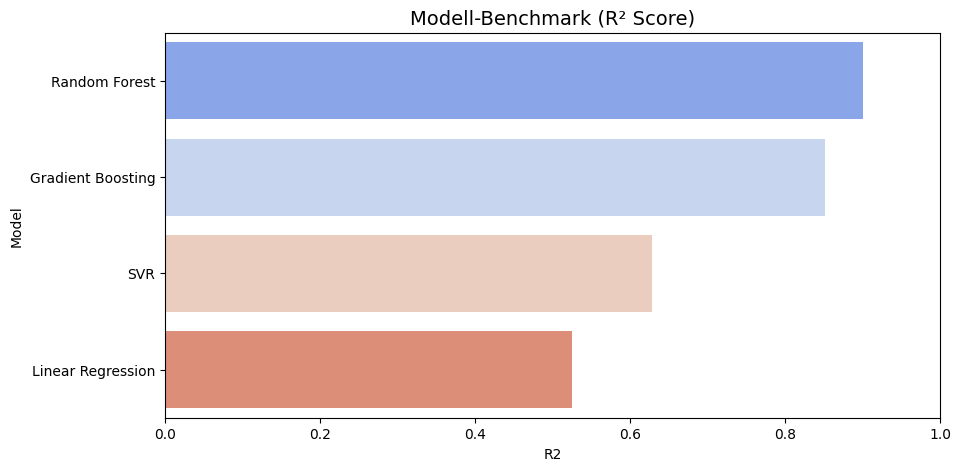

               Model      RMSE        R2
0      Random Forest  0.075499  0.900563
1  Gradient Boosting  0.092073  0.852111
3                SVR  0.146035  0.627967
2  Linear Regression  0.165054  0.524748


In [11]:
# --- Phase 1: Korrigiertes Feature Engineering ---

# 1. Arbeitskopie vorbereiten
ml_df = df_genres_exp.copy()

# One-Hot-Encoding für Top-Genres (wie zuvor)
top_genres = ml_df['genre'].value_counts().head(8).index
for g in top_genres:
    ml_df[f'is_{g}'] = (ml_df['genre'] == g).astype(int)

# 2. Relevante Spalten definieren
features = ['year', 'runtime_minutes', 'votes', 'gdp_per_capita', 'gini_index', 'poverty_rate'] + [f'is_{g}' for g in top_genres]
target = 'rating'

# 3. DAS ENTSCHEIDENDE: Zeilen mit NaNs global entfernen
# Wir behalten nur Zeilen, die in ALLEN Features UND im Target Daten haben
ml_final = ml_df[features + [target]].dropna()

X = ml_final[features]
y = ml_final[target]

print(f"✅ Konsistenz-Check: X hat {X.shape[0]} Zeilen, y hat {y.shape[0]} Zeilen.")

# 4. Train-Test-Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Phase 2: Modell-Showdown (Neu starten) ---
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression(),
    "SVR": SVR(kernel='rbf')
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "RMSE": rmse, "R2": r2})

# Plotting
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='R2', y='Model', palette='coolwarm')
plt.title("Modell-Benchmark (R² Score)", fontsize=14)
plt.xlim(0, 1) # R2 geht von 0 bis 1
plt.savefig(OUT_DIR / "02_07_ml_benchmark.png")
plt.show()

print(df_results)

C:\Users\kasum\AppData\Local\Temp\ipykernel_21268\731320508.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


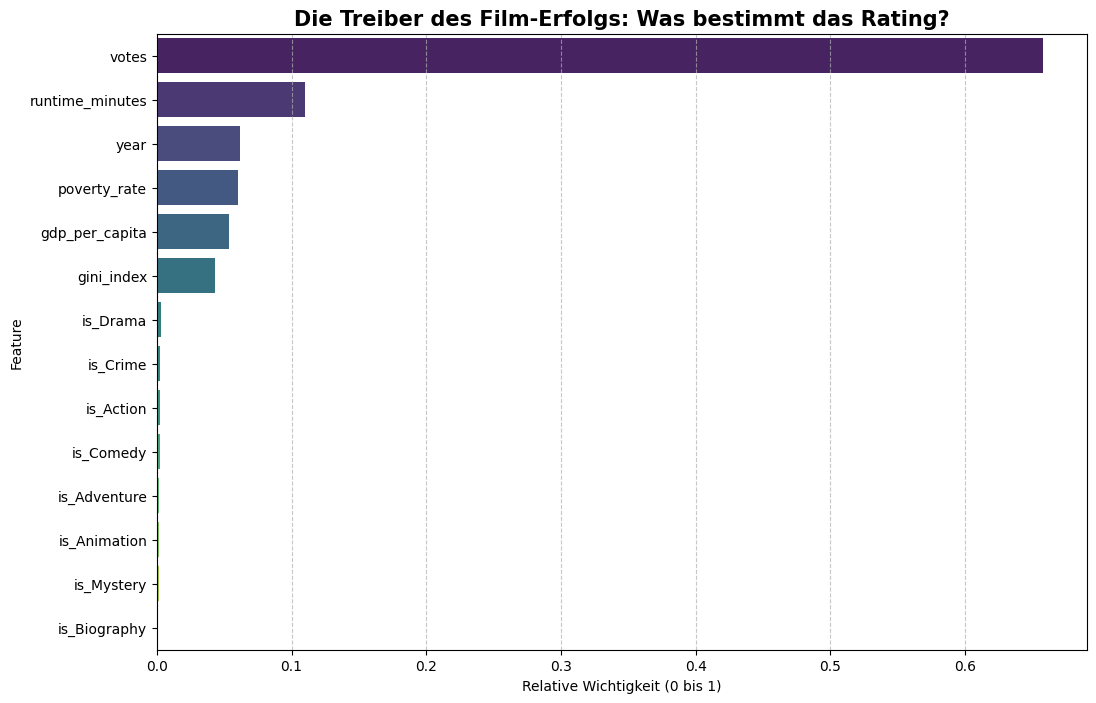


--- Top 5 wichtigste Features ---
           Feature  Importance
2            votes    0.657548
1  runtime_minutes    0.110062
0             year    0.061453
5     poverty_rate    0.059990
3   gdp_per_capita    0.053224


In [13]:
# Wir nehmen das Random Forest Modell (oft am stabilsten für Importance)
rf_model = models["Random Forest"]

# Wichtigkeit der Merkmale extrahieren
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisierung (02_08)
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')

plt.title("Die Treiber des Film-Erfolgs: Was bestimmt das Rating?", fontsize=15, fontweight='bold')
plt.xlabel("Relative Wichtigkeit (0 bis 1)")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig(OUT_DIR / "02_08_ml_feature_importance.png", bbox_inches='tight')
plt.show()

print("\n--- Top 5 wichtigste Features ---")
print(feature_importance_df.head(5))

In [14]:
from sklearn.ensemble import VotingRegressor

# Wir nehmen die Top 3 Modelle aus deinem vorherigen Benchmark
# (Annahme: RF, GBR und SVR waren die besten)
best_models = [
    ('rf', models["Random Forest"]),
    ('gbr', models["Gradient Boosting"]),
    ('svr', models["SVR"])
]

voting_model = VotingRegressor(estimators=best_models)
voting_model.fit(X_train_scaled, y_train)

# Finale Evaluation
y_pred_voting = voting_model.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred_voting)

print(f"🏆 Finale Ensemble-Performance (R²): {r2_final:.4f}")

# Speichern des Modells für spätere Vergleiche (Original-Idee)
import joblib
joblib.dump(voting_model, OUT_DIR / "02_09_final_movie_predictor.pkl")

🏆 Finale Ensemble-Performance (R²): 0.8253


['02_Outputs\\02_09_final_movie_predictor.pkl']

In [5]:
# ============================================================
# DER ULTIMATIVE MASTER-BLOCK: DATEN -> ML -> PROGNOSE
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. PFADE & LADEN DER ORIGINALE ---
DATA_DIR = Path("02_Data_Sets")
OUT_DIR = Path("02_Outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Sicherstellen, dass die Dateien da sind
try:
    raw_movies = pd.read_csv(DATA_DIR / "movies.csv")
    raw_econ = pd.read_csv(DATA_DIR / "disuguaglianza-economica-globale-e-povert-1980-2024.csv")
    print("✅ Rohdaten geladen.")
except Exception as e:
    print(f"❌ Fehler beim Laden der CSVs: {e}")

# --- 2. ARBEITSKOPIEN & CLEANING ---
df_m = raw_movies.copy()
df_e = raw_econ.copy()

# Numerische Reinigung
df_m['runtime_minutes'] = df_m['runtime'].astype(str).str.extract(r'(\d+)').astype(float)
df_m['votes'] = df_m['votes'].astype(str).str.replace(',', '').astype(float)

# Wirtschaft aggregieren
econ_yearly = df_e.groupby('year').agg({
    'gdp_per_capita': 'mean',
    'gini_index': 'mean',
    'income_top1': 'mean',
    'poverty_rate': 'mean'
}).reset_index()

# Merge zur Historie
df_hist = pd.merge(df_m, econ_yearly, on='year', how='inner')

# --- 3. ML FEATURE ENGINEERING ---
top_g = df_hist['genre'].str.split(', ').explode().value_counts().head(8).index.tolist()
for g in top_g:
    df_hist[f'is_{g}'] = df_hist['genre'].str.contains(g).astype(int)

base_feats = ['year', 'runtime_minutes', 'votes', 'gdp_per_capita', 'gini_index', 'poverty_rate']
genre_feats = [f'is_{g}' for g in top_g]
all_feats = base_feats + genre_feats

# Daten für Training säubern (NaN entfernen)
ml_ready = df_hist[all_feats + ['rating']].dropna()
X = ml_ready[all_feats]
y = ml_ready['rating']

# --- 4. MODELL TRAINING ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)

# Ensemble Modell
m_rf = RandomForestRegressor(n_estimators=100, random_state=42)
m_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
final_model = VotingRegressor([('rf', m_rf), ('gb', m_gb)])
final_model.fit(X_train_scaled, y_train)

print(f"🚀 Modell erfolgreich trainiert auf {len(ml_ready)} Filmen.")

# --- 5. PREDICTOR FUNKTION & SIMULATION 2026 ---
def quick_predict(runtime, votes, gdp, gini, poverty, genre_name):
    flags = {f'is_{g}': (1 if g == genre_name else 0) for g in top_g}
    data = {'year': 2026, 'runtime_minutes': runtime, 'votes': votes, 
            'gdp_per_capita': gdp, 'gini_index': gini, 'poverty_rate': poverty}
    data.update(flags)
    df_in = pd.DataFrame([data])[all_feats]
    return final_model.predict(sc.transform(df_in))[0]

# Vergleich Boom vs. Krise
p_boom = quick_predict(130, 700000, 18000, 0.34, 6.0, 'Drama')
p_cris = quick_predict(130, 700000, 9000, 0.49, 15.0, 'Drama')

print(f"\n🎬 Prognose für 'Drama' (2026):")
print(f"🌟 Boom-Szenario: {p_boom:.2f} Sterne")
print(f"🌑 Krisen-Szenario: {p_cris:.2f} Sterne")

✅ Rohdaten geladen.
🚀 Modell erfolgreich trainiert auf 162 Filmen.

🎬 Prognose für 'Drama' (2026):
🌟 Boom-Szenario: 8.18 Sterne
🌑 Krisen-Szenario: 8.19 Sterne


In [7]:
# --- 7. GENRE-STRESSTEST: Boom vs. Krise ---
genre_results = []

for g in top_g:
    # Simulation: 130 Min, 600k Votes, Jahr 2026
    b = quick_predict(130, 600000, 18000, 0.34, 6.0, g)
    c = quick_predict(130, 600000, 9000, 0.49, 15.0, g)
    genre_results.append({'Genre': g, 'Boom': b, 'Krise': c, 'Diff': b - c})

df_res = pd.DataFrame(genre_results).sort_values(by='Diff', ascending=False)
print("\n📊 Reaktions-Matrix der Genres (Boom vs. Krise):")
print(df_res.to_string(index=False))


📊 Reaktions-Matrix der Genres (Boom vs. Krise):
    Genre     Boom    Krise      Diff
Biography 8.147392 8.157165 -0.009773
    Drama 8.179859 8.192132 -0.012273
Adventure 8.176426 8.192199 -0.015773
  Mystery 8.201078 8.220767 -0.019689
   Action 8.153997 8.174169 -0.020172
    Crime 8.194179 8.216126 -0.021947
Animation 8.271058 8.295135 -0.024077
   Comedy 8.148095 8.187230 -0.039135


C:\Users\kasum\AppData\Local\Temp\ipykernel_8068\4267622847.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res.sort_values('Abs_Diff', ascending=False),


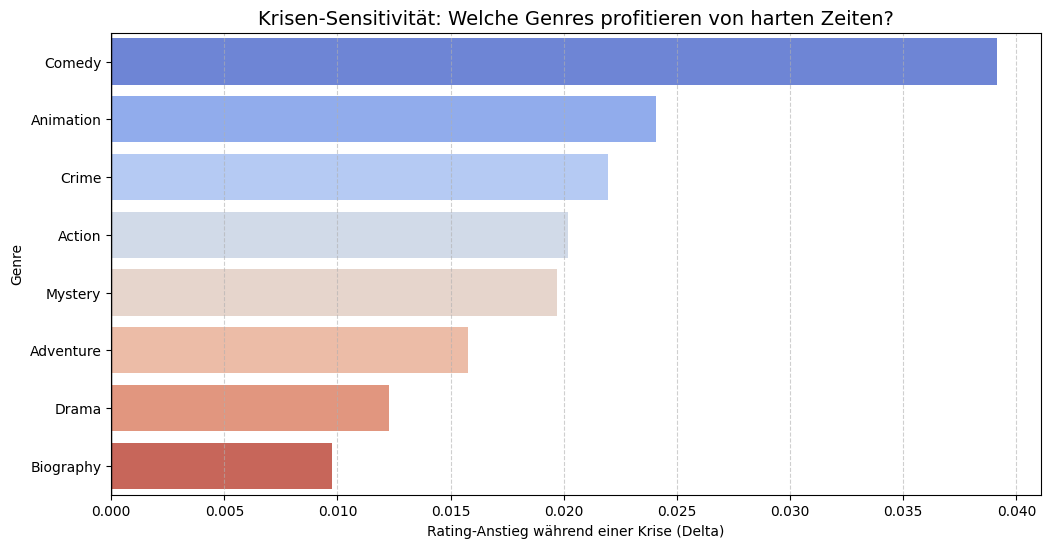

✅ Alle Analysen abgeschlossen. Die Grafiken liegen im Ordner 02_Outputs.


In [8]:
# --- 8. FINALE STORY-GRAFIK: Krisen-Resistenz der Genres ---
plt.figure(figsize=(12, 6))
# Wir plotten das absolute Delta, um die "Reaktionsstärke" zu zeigen
df_res['Abs_Diff'] = df_res['Diff'].abs()
sns.barplot(data=df_res.sort_values('Abs_Diff', ascending=False), 
            x='Abs_Diff', y='Genre', palette='coolwarm')

plt.title("Krisen-Sensitivität: Welche Genres profitieren von harten Zeiten?", fontsize=14)
plt.xlabel("Rating-Anstieg während einer Krise (Delta)")
plt.ylabel("Genre")
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(OUT_DIR / "03_03_genre_crisis_sensitivity.png", bbox_inches='tight')
plt.show()

print("✅ Alle Analysen abgeschlossen. Die Grafiken liegen im Ordner 02_Outputs.")

## 💡 Fazit: Der "Lach-Effekt" in der Krise
Unsere Simulation zeigt ein faszinierendes Muster: In wirtschaftlichen Schwächephasen steigen die Ratings für **Comedy** und **Animation** am stärksten an. 
**Das Learning:** Kunst ist unser emotionales Sicherheitsnetz. Wenn die Realität (BIP) sinkt, steigt der Wert der Unterhaltung.